# Writing data to and reading data from a Database using Python

## Libraries and settings

In [13]:
# Libraries
import os
import sqlite3
import fnmatch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# Function to close a sqlite db-connection
def check_conn(conn):
     try:
        conn.cursor()
        return True
     except Exception as ex:
        return False

# Get current working directory
print(os.getcwd())

/workspaces/data_analytics/Week_02


## Create sqlite data base

In [14]:
# Create data base
conn = sqlite3.connect('supermarket_database.db') 
cursor = conn.cursor()

# Show dbs in the directory
flist = fnmatch.filter(os.listdir('.'), '*.db')
for i in flist:
    print(i)

supermarket_database.db
apartment_database.db


## Create SQL-table in the database

In [15]:
cursor.execute('''CREATE TABLE IF NOT EXISTS supermarkets_table (Id VARCHAR(50),
                                                                  Brand VARCHAR(100),
                                                                  City VARCHAR(100),
                                                                  Street VARCHAR(200),
                                                                  Housenumber VARCHAR(20),
                                                                  Postcode VARCHAR(20),
                                                                  OpeningHours VARCHAR(200))''')
# Confirm changes to the table
conn.commit()

## Read data from file to data frame

In [16]:
## Read data from file to data frame
df = pd.read_json('supermarkets.json', encoding='utf-8')

# Extract fields from the nested 'tags' dictionary
df['brand'] = df['tags'].apply(lambda x: x.get('brand') if isinstance(x, dict) else None)
df['city'] = df['tags'].apply(lambda x: x.get('addr:city') if isinstance(x, dict) else None)
df['street'] = df['tags'].apply(lambda x: x.get('addr:street') if isinstance(x, dict) else None)
df['housenumber'] = df['tags'].apply(lambda x: x.get('addr:housenumber') if isinstance(x, dict) else None)
df['postcode'] = df['tags'].apply(lambda x: x.get('addr:postcode') if isinstance(x, dict) else None)
df['opening_hours'] = df['tags'].apply(lambda x: x.get('opening_hours') if isinstance(x, dict) else None)

# Select only the needed columns
df = df[['id', 'brand', 'city', 'street', 'housenumber', 'postcode', 'opening_hours']]

print(df.shape)
df.head(5)

(20, 7)


,id,brand,city,street,housenumber,postcode,opening_hours
0,33126515,Spar,None,None,None,None,Mo-Th 08:00-19:00; Fr 08:00-20:00; Sa 08:00-17:00
1,36726161,Migros,Uznach,Zürcherstrasse,25,8730,"Mo-Th 08:00-19:00, Fr 08:00-20:00, Sa 07:30-17..."
2,39768209,Coop,Uznach,None,None,8730,None
3,39947904,Coop,Zürich,Bahnhofbrücke,1,8001,Mo-Sa 06:00-22:00
4,48932835,Migros,Zürich,Wengistrasse,7,8004,Mo-Sa 08:00-21:00; PH off


## Write data to the SQL-table in data base

In [17]:
df.to_sql(name = 'supermarkets_table',
          con = conn,
          index = False,
          if_exists = 'replace')

20

## Query the SQL-table

In [18]:
# Query the SQL-table
cursor.execute('''SELECT *
               FROM supermarkets_table
               WHERE brand IS NOT NULL''')

df = pd.DataFrame(cursor.fetchall(), 
                  columns=['Id','Brand','City','Street','Housenumber','Postcode','OpeningHours'])    
df

,Id,Brand,City,Street,Housenumber,Postcode,OpeningHours
0,33126515,Spar,None,None,None,None,Mo-Th 08:00-19:00; Fr 08:00-20:00; Sa 08:00-17:00
1,36726161,Migros,Uznach,Zürcherstrasse,25,8730,"Mo-Th 08:00-19:00, Fr 08:00-20:00, Sa 07:30-17..."
2,39768209,Coop,Uznach,None,None,8730,None
3,39947904,Coop,Zürich,Bahnhofbrücke,1,8001,Mo-Sa 06:00-22:00
4,48932835,Migros,Zürich,Wengistrasse,7,8004,Mo-Sa 08:00-21:00; PH off
5,70656488,Migros,Winterthur,Zürcherstrasse,102,8406,Mo-Fr 07:30-20:00; PH off; Sa 08:00-19:00
6,75749133,ALDI,Zürich,Albisstrasse,81,8038,Mo-Sa 07:30-21:00
7,79977755,Coop,Zürich,Alte Kalchbühlstrasse,15,8038,Mo-Sa 07:30-21:00
8,81321513,Landi,None,None,None,None,"Mo-Sa 08:00-12:00, 13:30-18:00"
9,83330862,Migros,Zürich,Etzelstrasse,3,8038,Mo-Sa 07:30-21:00; PH off


## Additional SQL-queries

In [19]:
# g) Filter all supermarkets in the city of Winterthur
query_g = '''
SELECT *
FROM supermarkets_table
WHERE city = 'Winterthur'
'''
df_g = pd.read_sql_query(query_g, conn)
print(df_g)

         id   brand        city          street housenumber postcode  \
0  70656488  Migros  Winterthur  Zürcherstrasse         102     8406   

                               opening_hours  
0  Mo-Fr 07:30-20:00; PH off; Sa 08:00-19:00  


## Plot histogramm of rental prices

Text(0, 0.5, 'Count')

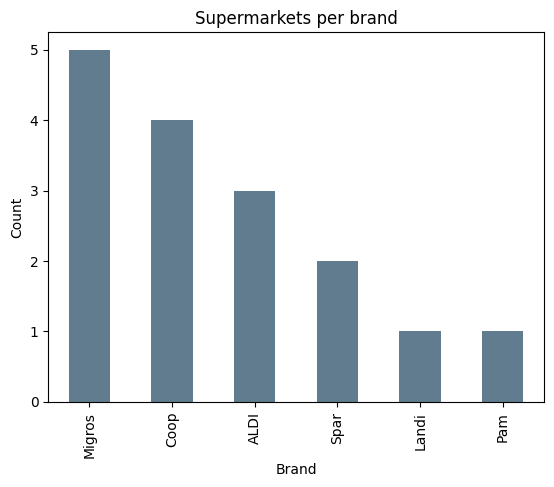

In [20]:
# Optional: Count supermarkets per brand
df.Brand.value_counts().plot.bar(color='#607c8e')
plt.title('Supermarkets per brand')
plt.xlabel('Brand')
plt.ylabel('Count')

## Close db connection (if open)

In [21]:
# Close db connection (if open)
try:
    if check_conn(conn):
        conn.close()
    else:
        pass
except:
    pass

# Status (True = open, False = closed)
print(check_conn(conn))

False


### Jupyter notebook --footer info-- (please always provide this at the end of each submitted notebook)

In [22]:
import os
import platform
import socket
from platform import python_version
from datetime import datetime

print('-----------------------------------')
print(os.name.upper())
print(platform.system(), '|', platform.release())
print('Datetime:', datetime.now().strftime("%Y-%m-%d %H:%M:%S"))
print('Python Version:', python_version())
print('-----------------------------------')

-----------------------------------
POSIX
Linux | 6.8.0-1064-azure
Datetime: 2026-09-26 11:47:05
Python Version: 3.11.16
-----------------------------------
